<a href="https://colab.research.google.com/github/GodishalaAshwith/DeepLearning/blob/main/DLInt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

List of Programs for Lab Internal 2

1. pre-trained models LeNet, AlexNet, ZF-Net, VGGNet, Google Inception Module, Resnet.
2. Visualizing Convolutional Neural Networks
3. Guided Backpropagation to discover which input pixels influence the perceptron.
4. Implement Auto Encoder model on MINIST dataset.
5. Implement Undercomplete AE and Overcomplete AE  
6. Implement Regularization in AE  
7. Implement denoising AE  
8. Demonstrate PCA with AE on a dataset.
9. Implement Sparse AE and Contractive AE.
10. Implement RNN for predicting the next character
11. Implement BERT model  
12. Implement GAN model on MNIST.

### pre-trained models LeNet, AlexNet, ZF-Net, VGGNet, Google Inception Module, Resnet.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# ================= DATA =================
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize and reshape for CNN
x_train, x_test = x_train/255.0, x_test/255.0
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)


# ================= LeNet-5 (Simplified) =================
# Original: tanh + subsampling | Here: ReLU + pooling for modern practice
lenet_model = models.Sequential([
    layers.Conv2D(6,5,activation='relu',padding='same',input_shape=(28,28,1)),
    layers.AveragePooling2D(2),
    layers.Conv2D(16,5,activation='relu'),
    layers.AveragePooling2D(2),
    layers.Flatten(),
    layers.Dense(120,activation='relu'),
    layers.Dense(84,activation='relu'),
    layers.Dense(10,activation='softmax')
])

lenet_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
lenet_model.fit(x_train,y_train,epochs=2,verbose=0)
print("LeNet Accuracy:", lenet_model.evaluate(x_test,y_test,verbose=0)[1])


# ================= AlexNet (Simplified) =================
# Original uses large kernels (11x11), dropout, LRN; adapted for 28x28 input
alexnet_model = models.Sequential([
    layers.Conv2D(64,3,activation='relu',padding='same',input_shape=(28,28,1)),
    layers.MaxPooling2D(2),
    layers.Conv2D(128,3,activation='relu',padding='same'),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,activation='softmax')
])

alexnet_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
alexnet_model.fit(x_train,y_train,epochs=2,verbose=0)
print("AlexNet Accuracy:", alexnet_model.evaluate(x_test,y_test,verbose=0)[1])


# ================= ZF-Net (Simplified) =================
# Improvement over AlexNet: smaller stride & better feature capture
zf_model = models.Sequential([
    layers.Conv2D(64,3,strides=1,activation='relu',padding='same',input_shape=(28,28,1)),
    layers.MaxPooling2D(2),
    layers.Conv2D(128,3,activation='relu',padding='same'),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dense(10,activation='softmax')
])

zf_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
zf_model.fit(x_train,y_train,epochs=2,verbose=0)
print("ZF-Net Accuracy:", zf_model.evaluate(x_test,y_test,verbose=0)[1])


# ================= VGG (Mini VGG) =================
# VGG uses stacked 3x3 conv layers; depth reduced for MNIST
vgg_model = models.Sequential([
    layers.Conv2D(32,3,activation='relu',padding='same',input_shape=(28,28,1)),
    layers.Conv2D(32,3,activation='relu',padding='same'),
    layers.MaxPooling2D(2),

    layers.Conv2D(64,3,activation='relu',padding='same'),
    layers.Conv2D(64,3,activation='relu',padding='same'),
    layers.MaxPooling2D(2),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

vgg_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
vgg_model.fit(x_train,y_train,epochs=1,verbose=0)
print("VGG Accuracy:", vgg_model.evaluate(x_test,y_test,verbose=0)[1])


# ================= Inception (Simplified Module) =================x`
# Parallel filters: 1x1, 3x3, and pooling branches
inp = layers.Input(shape=(28,28,1))

c1 = layers.Conv2D(16,1,activation='relu',padding='same')(inp)
c2 = layers.Conv2D(16,3,activation='relu',padding='same')(inp)
c3 = layers.MaxPooling2D(3,strides=1,padding='same')(inp)

x = layers.concatenate([c1,c2,c3])
x = layers.Flatten()(x)
out = layers.Dense(10,activation='softmax')(x)

inception_model = models.Model(inp,out)
inception_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
inception_model.fit(x_train,y_train,epochs=1,verbose=0)
print("Inception Accuracy:", inception_model.evaluate(x_test,y_test,verbose=0)[1])


# ================= ResNet (Basic Residual Block) =================
# Skip connection helps avoid vanishing gradient
inp = layers.Input(shape=(28,28,1))

x = layers.Conv2D(32,3,padding='same',activation='relu')(inp)
skip = x

x = layers.Conv2D(32,3,padding='same')(x)
x = layers.Add()([x,skip])
x = layers.Activation('relu')(x)

x = layers.Flatten()(x)
out = layers.Dense(10,activation='softmax')(x)

resnet_model = models.Model(inp,out)
resnet_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
resnet_model.fit(x_train,y_train,epochs=1,verbose=0)
print("ResNet Accuracy:", resnet_model.evaluate(x_test,y_test,verbose=0)[1])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LeNet Accuracy: 0.9833999872207642
AlexNet Accuracy: 0.9902999997138977
ZF-Net Accuracy: 0.9904000163078308
VGG Accuracy: 0.9833999872207642
Inception Accuracy: 0.9724000096321106
ResNet Accuracy: 0.9787999987602234


### Visualizing Convolutional Neural Networks

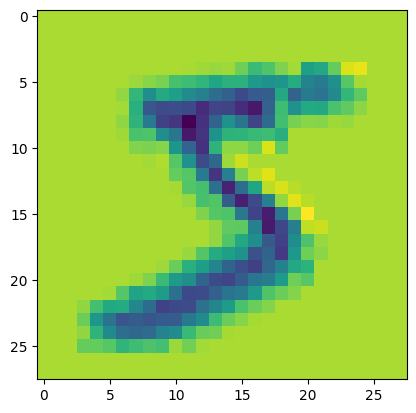

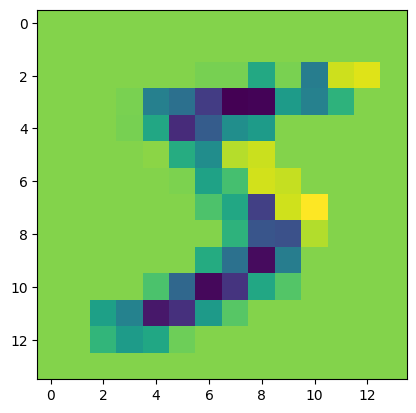

In [22]:
import torch, matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch.nn as nn

# Load one MNIST image
img,_ = datasets.MNIST('./data', train=True, download=True,
                       transform=transforms.ToTensor())[0]

# Conv + Pool
x = img.unsqueeze(0)
conv = nn.Conv2d(1,8,3,padding=1)(x)
pool = nn.MaxPool2d(2)(conv)

# Plot
def show(t):
    t = t.squeeze().detach()
    for i in range(t.shape[0]):
        plt.imshow(t[i])
    plt.show()

show(conv)
show(pool)

### Guided Backpropogation

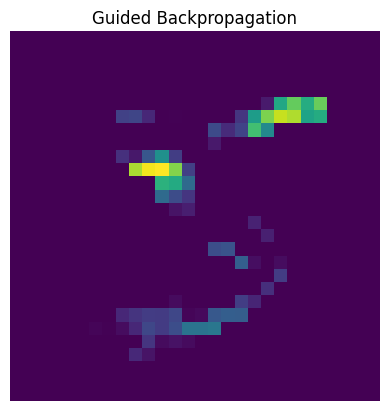

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load + preprocess
(x, y), _ = mnist.load_data()
x = x.astype("float32")/255.0
x = x[..., None]

# Simple CNN
model = models.Sequential([
    layers.Conv2D(8, 3, activation='relu', input_shape=(28,28,1)),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
model.fit(x, y, epochs=1, verbose=0)

# Pick one sample
img = tf.convert_to_tensor(x[:1])

# Guided Backprop (positive gradients + positive activations)
with tf.GradientTape() as tape:
    tape.watch(img)
    preds = model(img)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, img)

# Guided filtering (true idea)
guided = tf.nn.relu(grads) * tf.cast(img > 0, tf.float32)

# Visualize
plt.imshow(guided[0,:,:,0])
plt.title("Guided Backpropagation")
plt.axis('off')
plt.show()

### Implement Auto Encoder model on MINIST dataset.

In [26]:
# 4. Implement Auto Encoder model on MINIST dataset
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# data
(x_train, _), _ = mnist.load_data()
x_train = x_train/255.0
x_train = x_train.reshape(-1,28*28)

print("Data shape:", x_train.shape)

# autoencoder
model = models.Sequential([
    layers.Dense(64,activation='relu',input_shape=(784,)),
    layers.Dense(784,activation='sigmoid')
])

model.compile(optimizer='adam', loss='mse')

# train
model.fit(x_train,x_train,epochs=2,verbose=0)

print("Training done")

# test reconstruction
out = model.predict(x_train[:1])

print("Input shape:", x_train[:1].shape)
print("Output shape:", out.shape)
print("Sample output values:", out[0][:5])

Data shape: (60000, 784)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training done
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
Input shape: (1, 784)
Output shape: (1, 784)
Sample output values: [2.7919818e-09 3.5113936e-09 3.2074844e-08 4.6901260e-08 1.0226192e-08]


### Implement Undercomplete AE and Overcomplete AE

In [28]:
# 5. Implement Undercomplete AE and Overcomplete AE
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# data
(x_train, _), _ = mnist.load_data()
x_train = x_train/255.0
x_train = x_train.reshape(-1,784)

print("Data loaded:", x_train.shape)

# -------- Undercomplete AE --------
model = models.Sequential([
    layers.Dense(32,activation='relu',input_shape=(784,)),  # smaller
    layers.Dense(784,activation='sigmoid')
])

model.compile(optimizer='adam',loss='mse')
model.fit(x_train,x_train,epochs=2,verbose=0)

out1 = model.predict(x_train[:1])
print("Undercomplete output shape:", out1.shape)


# -------- Overcomplete AE --------
model = models.Sequential([
    layers.Dense(1024,activation='relu',input_shape=(784,)),  # larger
    layers.Dense(784,activation='sigmoid')
])

model.compile(optimizer='adam',loss='mse')
model.fit(x_train,x_train,epochs=2,verbose=0)

out2 = model.predict(x_train[:1])
print("Overcomplete output shape:", out2.shape)

Data loaded: (60000, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
Undercomplete output shape: (1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step
Overcomplete output shape: (1, 784)
